<a href="https://colab.research.google.com/github/KweonTJ/Artifical_Intelligence-ML-NN-/blob/main/lec04_linear_regression_univariate_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 단변량 선형 회귀 (Univariate Linear Regression) 실습

이 실습에서는 단변량 선형 회귀를 두 가지 방법으로 구현합니다:
1. scipy.optimize를 이용한 방법
2. Gradient Descent를 직접 구현한 방법

**총점: 100점**

**학번:** 2023042028\
**이름:** 권택주

---
## Part 1: 데이터셋 생성 및 시각화 (10점)

선형 관계를 가진 데이터셋을 생성하고 시각화합니다.

---

### 문제 1-1. 데이터셋 시각화 [10점]

주어진 데이터셋:
- x = [1.78, 6.12, 6.63, 4.13, 8.55, 10.92, 4.81, 3.75, 2.28, 5.74]
- y = [1.06, 3.04, 3.93, 2.19, 4.89, 5.37, 2.91, 2.36, 1.13, 3.05]

**문제:** 데이터를 scatter plot으로 시각화하세요.

**예상 결과:** x와 y가 양의 선형 관계를 보이는 산점도

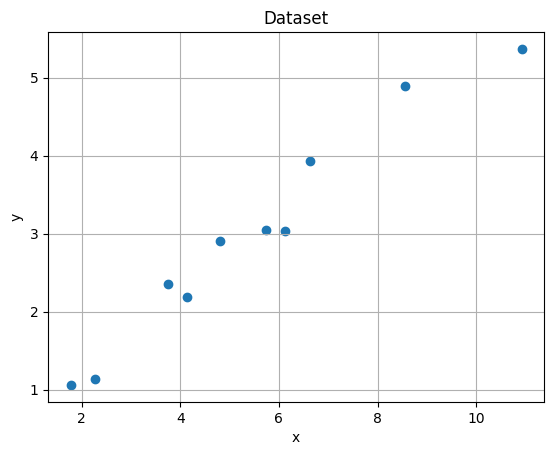

In [1]:
#@title { vertical-output: true}
import numpy as np
import matplotlib.pyplot as plt

x = np.array([1.78, 6.12, 6.63, 4.13, 8.55, 10.92, 4.81, 3.75, 2.28, 5.74])
y = np.array([1.06, 3.04, 3.93, 2.19, 4.89, 5.37, 2.91, 2.36, 1.13, 3.05])

plt.scatter(x, y)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Dataset')
plt.grid(True)
plt.show()

---
## Part 2: scipy.optimize를 이용한 선형 회귀 (40점)

손실 함수(MSE)를 정의하고 scipy.optimize.minimize를 사용하여 최적의 파라미터를 찾습니다.

**선형 회귀 모델:** $\hat{y} = wx + b$

**손실 함수 (MSE):** $L(w, b) = \frac{1}{n}\sum_{i=1}^{n}(\hat{y}_i - y_i)^2$

---

### 문제 2-1. 손실 함수 (OLS Loss) 정의 [20점]

Mean Squared Error(MSE)를 계산하는 손실 함수를 구현합니다.

**문제:** `ols_loss` 함수에서 `y_hat`과 `mse`를 계산하세요.

**힌트:**
- y_hat = w * x + b
- mse = np.mean((y_hat - y) ** 2)

In [2]:
#@title { vertical-output: true}
def ols_loss(params, x, y):
    """
    OLS (Ordinary Least Squares) 손실 함수

    Parameters:
    - params: [w, b] 파라미터
    - x: 입력 데이터
    - y: 실제 값

    Returns:
    - mse: Mean Squared Error
    """
    w, b = params

    # IMPLEMENT HERE
    y_hat = w*x + b
    mse = np.mean((y_hat - y) ** 2)

    return mse

### 문제 2-2. scipy.optimize.minimize 사용 [20점]

`scipy.optimize.minimize`를 사용하여 손실 함수를 최소화하는 파라미터를 찾습니다.

**사용법:**
```python
result = optimize.minimize(손실함수, 초기값, args=(x, y))
```

**문제:** 초기값 [1.0, 1.0]에서 시작하여 최적의 w, b를 찾으세요.

**예상 결과:**
```
x: [ 5.031e-01  2.403e-01]
```
(w ≈ 0.503, b ≈ 0.240)

In [3]:
#@title { vertical-output: true}
from scipy import optimize

# IMPLEMENT HERE: optimize.minimize 사용
result = optimize.minimize(ols_loss, [1.0, 1.0], args=(x, y))

print(result)
w_opt, b_opt = result.x
print(f"\n최적 파라미터: w = {w_opt:.4f}, b = {b_opt:.4f}")

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 0.06684729140805669
        x: [ 5.031e-01  2.403e-01]
      nit: 6
      jac: [ 8.382e-09 -9.313e-10]
 hess_inv: [[ 7.141e-02 -3.907e-01]
            [-3.907e-01  2.637e+00]]
     nfev: 21
     njev: 7

최적 파라미터: w = 0.5031, b = 0.2403


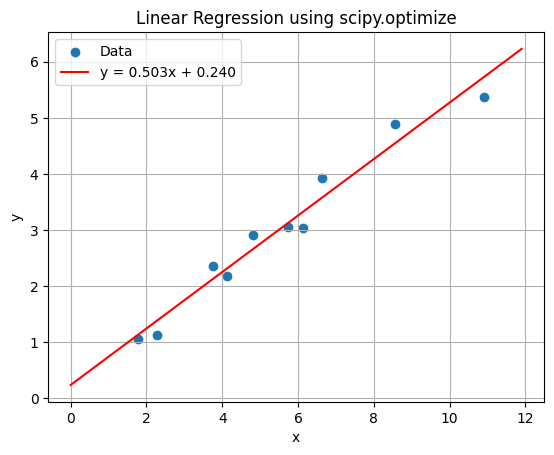

In [4]:
#@title { vertical-output: true}
# 결과 시각화
x_test = np.arange(0, 12, 0.1)
y_hat = w_opt * x_test + b_opt

plt.scatter(x, y, label='Data')
plt.plot(x_test, y_hat, c='red', label=f'y = {w_opt:.3f}x + {b_opt:.3f}')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Linear Regression using scipy.optimize')
plt.legend()
plt.grid(True)
plt.show()

---
## Part 3: Gradient Descent 직접 구현 (50점)

Gradient Descent 알고리즘을 직접 구현하여 선형 회귀를 수행합니다.

**그래디언트 공식:**
- $\frac{\partial L}{\partial w} = \frac{2}{n}\sum_{i=1}^{n}(wx_i + b - y_i) \cdot x_i$
- $\frac{\partial L}{\partial b} = \frac{2}{n}\sum_{i=1}^{n}(wx_i + b - y_i)$

---

### 문제 3-1. 그래디언트 계산 함수 [25점]

손실 함수에 대한 그래디언트를 계산하는 함수를 구현합니다.

**문제:** `compute_gradient` 함수에서 `grad_w`와 `grad_b`를 계산하세요.

**힌트:**
- grad_w = (2/n) * np.sum((w*x + b - y) * x)
- grad_b = (2/n) * np.sum(w*x + b - y)

In [5]:
#@title { vertical-output: true}
def compute_gradient(params, x, y):
    """
    손실 함수에 대한 그래디언트 계산

    Parameters:
    - params: [w, b] 파라미터
    - x: 입력 데이터
    - y: 실제 값

    Returns:
    - np.array([grad_w, grad_b]): 그래디언트
    """
    w, b = params
    n = len(x)

    # IMPLEMENT HERE
    grad_w = (2/n) * np.sum((w*x + b - y) * x)
    grad_b = (2/n) * np.sum(w*x + b -y)

    return np.array([grad_w, grad_b])

### 문제 3-2. Gradient Descent Minimize 함수 [25점]

Gradient Descent를 사용하여 파라미터를 업데이트하는 함수를 구현합니다.

**알고리즘:**
```
for each iteration:
    gradient = compute_gradient([w, b], x, y)
    w = w - learning_rate * gradient[0]
    b = b - learning_rate * gradient[1]
```

**문제:** `minimize` 함수의 for 루프 내부를 완성하세요.

**예상 결과:**
```
w ≈ 0.503, b ≈ 0.240
```

In [6]:
#@title { vertical-output: true}
def minimize(x, y, learning_rate=0.01, num_iterations=1000):
    """
    Gradient Descent를 사용하여 선형 회귀 파라미터 학습

    Parameters:
    - x: 입력 데이터
    - y: 실제 값
    - learning_rate: 학습률
    - num_iterations: 반복 횟수

    Returns:
    - w, b: 학습된 파라미터
    """
    w, b = 0, 0

    for _ in range(num_iterations):
        # IMPLEMENT HERE
        gradient = compute_gradient([w, b], x, y)
        w = w - learning_rate * gradient[0]
        b = b - learning_rate * gradient[1]

    return w, b

최적 파라미터: w = 0.5037, b = 0.2364


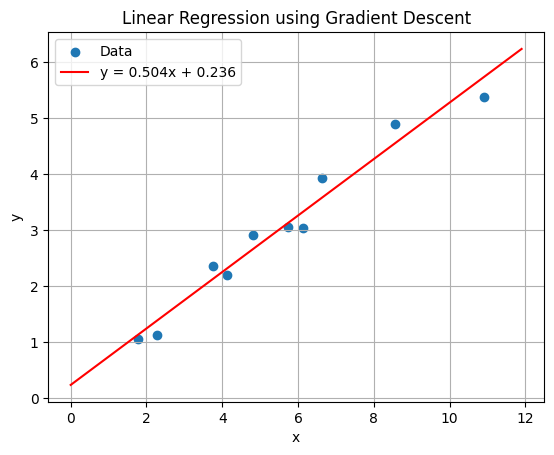

In [7]:
#@title { vertical-output: true}
# Gradient Descent 실행
w_opt, b_opt = minimize(x, y)
print(f"최적 파라미터: w = {w_opt:.4f}, b = {b_opt:.4f}")

# 결과 시각화
x_test = np.arange(0, 12, 0.1)
y_hat = w_opt * x_test + b_opt

plt.scatter(x, y, label='Data')
plt.plot(x_test, y_hat, c='red', label=f'y = {w_opt:.3f}x + {b_opt:.3f}')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Linear Regression using Gradient Descent')
plt.legend()
plt.grid(True)
plt.show()

---
## 제출 안내

1. 모든 문제를 완성한 후, 코드 셀을 실행하여 결과를 확인하세요.
2. **제출 파일:**
   - `.ipynb` 파일
   - `.pdf` 파일 (파일 > 인쇄 > PDF로 저장)
3. 파일명: `linear_regression_univariate_학번_이름.ipynb`, `linear_regression_univariate_학번_이름.pdf`
4. LMS에 두 파일을 함께 제출하세요.

**주의:** 기한 내에 제출하지 않으면 감점이 있습니다.

---